# Домашнее задание 1: EDA. Регрессия

Фамилия и имя студента: **НАПИШИТЕ ЗДЕСЬ**

----

Уважаемые студенты,

Это домашнее задание включает задачи по подготовке данных, визуализации и регрессии. Выполните все задания и отправьте `.ipynb`-файл с кодом и графиками. Также нужно сдать `.html`-отчёт с EDA (см. конец задания 1). Оба файла отправляются в **SmartLMS**. Не забудьте указать фамилию и имя в названиях файлов.

Обратите внимание: это **индивидуальная работа**. Плагиат, списывание или использование чужого кода без указания источника не допускаются.


## Задание 1: чтение данных и первичный осмотр (0–2 балла)

Будем использовать следующие данные.

**Целевая переменная:**
- `EARNMTHALL` — ежемесячный заработок с учётом бонусов для наёмных работников и самозанятых.

**Признаки:**
- `AGE_R` — возраст, лет
- `GENDER_R` — пол, 1: мужчина, 2: женщина
- `I_Q08` — состояние здоровья, 1: excellent, 2: very good, 3: good, 4: fair, 5: poor
- `J_Q03a` — дети, 1: да, 2: нет
- `PARED` — максимальный уровень образования матери или отца, 1: ни один из родителей не получил полное среднее, 2: как минимум один из родителей получил полное среднее, 3: как минимум один из родителей имеет высшее
- `D_Q03` — сектор занятости, 1: частный, 2: государственный, 3: НКО
- `D_Q06a` — размер фирмы, 1: 1–10, 2: 11–50, 3: 51–250, 4: 251–1000, 5: более 1000
- `D_Q10` — рабочие часы в неделю
- `NFE12JR` — проходил ли человек курсы за последние 12 месяцев, 1: да, 2: нет
- `ISCO1C` — профессия, 1: руководители, 2: профессионалы, 3: техники и младшие специалисты, 4: служащие, 5: работники сферы услуг и продаж, 6: квалифицированные работники сельского/лесного/рыбного хозяйства, 7: ремесленники и рабочие родственных профессий, 8: операторы и сборщики, 9: простые профессии, 10: вооружённые силы
- `ISCOSKIL4` — требуемый уровень навыков по профессии, 1: высокий, 2: средний, 3: низкий
- `LEARNATWORK`, `PLANNING`, `INFLUENCE`, `TASKDISC`, `READHOME` — непрерывные шкалы, по которым большее значение означает более развитый навык
- `PVNUM1` — тестовая оценка по математике
- `PVLIT1` — тестовая оценка по грамотности

Используйте готовый датафрейм `piaac`.


In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

# Для Jupyter/Scientific Mode: графики отображаются прямо в ячейке
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

warnings.simplefilter("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

sns.set(style="darkgrid")

In [97]:
#скачаем датасет, если его нет в папке с ноутбуком
import urllib.request
from pathlib import Path

url = 'https://webfs.oecd.org/piaac/cy1-puf-data/CSV/prgrusp1.csv'
file_name = Path('prgrusp1.csv')

if not file_name.exists():
    urllib.request.urlretrieve(url, file_name)

print(file_name.exists())

True


In [98]:
cols = ['EARNMTHALL', 'AGE_R', 'GENDER_R', 'I_Q08', 'J_Q03a', 'PARED', 'EDCAT6', 'NFE12JR', 'LEARNATWORK', 'PAIDWORK12', 'D_Q03', 'D_Q06a', 'D_Q10', 'ISCOSKIL4', 'ISCO1C', 'READHOME', 'TASKDISC','PLANNING', 'INFLUENCE', 'PVLIT1', 'PVNUM1']

data = pd.read_csv('prgrusp1.csv',    #Your path to the data file here
                   usecols = cols,
                   na_values = {'GENDER_R':'N',
                                'I_Q08':['D','N','R','V'],
                                'J_Q03a':['D','N','R','V'],
                                'PARED':['D','N','R','V'],
                                'EDCAT6':'N',
                                'NFE12JR':['N','U'],
                                'LEARNATWORK':['V','N'],
                                'PAIDWORK12':'N',
                                'D_Q03': ['D','N','R','V'],
                                'D_Q06a':['D','N','R','V'],
                                'D_Q10':['D','N','R','V'],
                                'ISCOSKIL4':['U','N'],
                                'ISCO1C':[9995,9996,9997,9998,9999],
                                'EARNMTHALL': ['V','N'],
                                'READHOME': ['V','N'],
                                'TASKDISC': ['V','N'],
                                'PLANNING': ['V','N'],
                                'INFLUENCE': ['V','N'],
                                'PVLIT1': ['V','N'],
                                'PVNUM1': ['V','N']}
                  )

### Посмотрите на данные
- покажите информацию о столбцах: название, число непустых значений и тип данных;
- покажите первые 10 наблюдений.


In [99]:
#используем data.info(), один из базовых методов в pandas для получения информации о датасете
data.info()
#аналогично и для data.head(), в значение параметра передадим число 10 - требуемое число строк
data.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3892 entries, 0 to 3891
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AGE_R        3892 non-null   int64  
 1   GENDER_R     3891 non-null   float64
 2   D_Q03        2219 non-null   float64
 3   D_Q06a       1945 non-null   float64
 4   D_Q10        2179 non-null   float64
 5   I_Q08        3869 non-null   float64
 6   J_Q03a       3889 non-null   float64
 7   PARED        3598 non-null   float64
 8   EDCAT6       3890 non-null   float64
 9   PAIDWORK12   3890 non-null   float64
 10  ISCOSKIL4    3381 non-null   object 
 11  ISCO1C       2175 non-null   float64
 12  PVLIT1       3892 non-null   float64
 13  PVNUM1       3892 non-null   float64
 14  NFE12JR      3683 non-null   float64
 15  EARNMTHALL   1852 non-null   float64
 16  LEARNATWORK  1898 non-null   float64
 17  INFLUENCE    2317 non-null   float64
 18  PLANNING     2291 non-null   float64
 19  READHO

,AGE_R,GENDER_R,D_Q03,D_Q06a,D_Q10,I_Q08,J_Q03a,PARED,EDCAT6,PAIDWORK12,ISCOSKIL4,ISCO1C,PVLIT1,PVNUM1,NFE12JR,EARNMTHALL,LEARNATWORK,INFLUENCE,PLANNING,READHOME,TASKDISC
0,41,2.0,2.0,4.0,20.0,5.0,2.0,2.0,5.0,1.0,1,3.0,330.50218,305.30869,0.0,6833.333333,2.295177,0.790227,1.315927,2.011665,1.369796
1,29,2.0,2.0,2.0,36.0,3.0,2.0,3.0,6.0,1.0,1,2.0,282.35156,266.30648,0.0,17083.333333,1.501159,1.891198,1.752098,1.235917,2.134559
2,53,1.0,2.0,4.0,40.0,4.0,1.0,2.0,6.0,1.0,1,2.0,285.95787,284.63605,0.0,10000.000000,-0.204802,0.366385,1.068287,1.212887,0.696290
3,16,2.0,1.0,1.0,10.0,3.0,2.0,3.0,1.0,0.0,3,7.0,248.84926,293.19744,0.0,NaN,2.047110,1.520208,1.752098,1.507855,1.781198
4,24,2.0,1.0,3.0,40.0,3.0,1.0,2.0,6.0,1.0,2,4.0,260.96999,264.24711,0.0,25000.000000,1.445971,0.109295,1.752098,0.276765,1.168926
5,20,2.0,NaN,NaN,NaN,2.0,2.0,3.0,2.0,0.0,A,NaN,253.73814,245.66418,0.0,NaN,NaN,NaN,NaN,0.795500,NaN
6,44,2.0,1.0,NaN,40.0,3.0,1.0,2.0,6.0,1.0,1,2.0,295.13639,281.70096,0.0,16666.666667,NaN,0.109295,1.752098,2.001743,2.311937
7,55,2.0,NaN,NaN,NaN,4.0,1.0,1.0,4.0,0.0,A,NaN,319.08829,311.40708,0.0,NaN,NaN,NaN,NaN,2.435358,NaN
8,26,2.0,3.0,2.0,40.0,3.0,2.0,NaN,5.0,1.0,2,5.0,271.55067,282.60500,0.0,NaN,2.040772,2.086384,1.958027,1.740080,1.026250
9,62,2.0,NaN,NaN,NaN,4.0,1.0,1.0,2.0,0.0,NaN,NaN,203.39526,174.06033,0.0,NaN,NaN,NaN,NaN,NaN,NaN


### Переименование
- переведите все имена переменных в нижний регистр;
- переименуйте переменные `['d_q03','d_q06a','d_q10','i_q08','j_q03a','edcat6','iscoskil4','isco1c','nfe12jr']` в `['sector','firmsize','workhours','health','children','education','skills','occupation','courses']`.


In [100]:
#приведем существующие столбцы в нижний регистр
data.columns=data.columns.str.lower()
existing_col=[
    'd_q03','d_q06a','d_q10','i_q08','j_q03a','edcat6','iscoskil4','isco1c','nfe12jr'
]
new_col=[
    'sector','firmsize','workhours','health','children','education','skills','occupation','courses'
]
#соединим existing_col и new_col в словарь
rename_dict=dict(zip(existing_col, new_col))
#переименуем столбцы при помощи встроенного метода rename
data.rename(columns = rename_dict, inplace=True)
#проверим результат
data.head()


,age_r,gender_r,sector,firmsize,workhours,health,children,pared,education,paidwork12,skills,occupation,pvlit1,pvnum1,courses,earnmthall,learnatwork,influence,planning,readhome,taskdisc
0,41,2.0,2.0,4.0,20.0,5.0,2.0,2.0,5.0,1.0,1,3.0,330.50218,305.30869,0.0,6833.333333,2.295177,0.790227,1.315927,2.011665,1.369796
1,29,2.0,2.0,2.0,36.0,3.0,2.0,3.0,6.0,1.0,1,2.0,282.35156,266.30648,0.0,17083.333333,1.501159,1.891198,1.752098,1.235917,2.134559
2,53,1.0,2.0,4.0,40.0,4.0,1.0,2.0,6.0,1.0,1,2.0,285.95787,284.63605,0.0,10000.000000,-0.204802,0.366385,1.068287,1.212887,0.696290
3,16,2.0,1.0,1.0,10.0,3.0,2.0,3.0,1.0,0.0,3,7.0,248.84926,293.19744,0.0,NaN,2.047110,1.520208,1.752098,1.507855,1.781198
4,24,2.0,1.0,3.0,40.0,3.0,1.0,2.0,6.0,1.0,2,4.0,260.96999,264.24711,0.0,25000.000000,1.445971,0.109295,1.752098,0.276765,1.168926


### Фильтрация
- оставьте только респондентов, которые работали в течение 12 месяцев до опроса, не служили в вооружённых силах и работали менее 81 часа в неделю;
- удалите переменную `paidwork12`;
- удалите наблюдения с пропущенным значением `earnmthall`.


In [101]:
#отфильтруем данные при помощи df[(column_name) condition value]
data = data[
    (data['paidwork12'] == 1) &
    (data['occupation'] != 0) &
    (data['workhours'] < 81)
]
#удалим столбец paidwork12 при помощи метода drop
data = data.drop(columns='paidwork12')
#удалим наблюдения с пропущенным значением в столбце earnmthall при помощи метода dropna
data = data.dropna(subset=['earnmthall'])
data.describe()


,age_r,gender_r,sector,firmsize,workhours,health,children,pared,education,occupation,pvlit1,pvnum1,courses,earnmthall,learnatwork,influence,planning,readhome,taskdisc
count,1827.000000,1826.000000,1826.000000,1635.000000,1827.000000,1818.000000,1826.000000,1732.000000,1825.000000,1812.000000,1827.000000,1827.000000,1816.000000,1.827000e+03,1583.000000,1638.000000,1630.000000,1767.000000,1723.000000
mean,36.220033,1.636364,1.382256,2.524159,38.739464,3.045655,1.427163,2.231524,4.476712,3.901214,283.454691,277.884313,0.253304,1.893876e+04,1.859325,2.018148,1.973354,1.433722,1.686090
std,12.473138,0.481177,0.512413,1.180159,12.205030,1.005546,0.494802,0.742441,1.533482,2.341770,39.603938,38.350077,0.435023,6.948637e+04,1.112321,1.001132,0.998475,1.020347,0.929261
min,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,133.770160,136.110760,0.000000,8.333333e-02,-0.643564,0.064147,0.101330,-1.298560,-0.232405
25%,25.000000,1.000000,1.000000,2.000000,36.000000,3.000000,1.000000,2.000000,3.000000,2.000000,257.829205,254.003075,0.000000,8.666667e+03,1.145677,1.370708,1.310491,0.828357,1.008896
50%,34.000000,2.000000,1.000000,2.000000,40.000000,3.000000,1.000000,2.000000,4.000000,3.000000,285.341400,280.140960,0.000000,1.400000e+04,1.741595,1.986698,1.752098,1.478156,1.551756
75%,46.000000,2.000000,2.000000,3.000000,45.000000,4.000000,2.000000,3.000000,6.000000,5.000000,311.041310,304.340325,1.000000,2.037500e+04,2.442307,2.544151,3.010131,2.096310,2.222203
max,65.000000,2.000000,3.000000,5.000000,80.000000,5.000000,2.000000,3.000000,6.000000,9.000000,407.183490,383.842020,1.000000,2.704167e+06,4.162505,5.579842,3.734814,7.427246,4.304112


### Осмотр
Сделайте html-отчёт с помощью [ydata_profiling](https://pypi.org/project/ydata-profiling/). Этот отчёт тоже нужно сдать.


In [102]:
#from ydata_profiling import ProfileReport
#profile = ProfileReport(data)
#profile.to_file("piaac_eda_report.html")


## Задание 2: перекодировка и заполнение пропусков (0–2 балла)

Глядя на графики в отчёте, можно заметить, что, во‑первых, целевую переменную стоит преобразовать, а во‑вторых, в некоторых качественных переменных слишком мало наблюдений в отдельных категориях, поэтому требуется перекодировка.

### Перекодируйте качественные переменные
- в `sector` перекодируйте 3 в 2;
- в `health` перекодируйте 1 в `'very good'`, 2 в `'very good'`, 3 в `'good'`, 4 в `'poor'`, 5 в `'poor'`;
- в `education` перекодируйте 1 в `'general'`, 2 в `'general'`, 3 в `'general'`, 4 в `'vocational'`, 5 в `'vocational'`, 6 в `'higher'`;
- в `skills` перекодируйте 1 в `'high'`, 2 в `'middle'`, 3 в `'low'`;
- в `occupation` перекодируйте 1 в `'high'`, 2 в `'high'`, 3 в `'middle'`, 4 в `'middle'`, 5 в `'middle'`, 6 в `'middle'`, 7 в `'middle'`, 8 в `'middle'`, 9 в `'low'`;
- в `firmsize` перекодируйте 1 в `'small'`, 2 в `'small'`, 3 в `'small'`, 4 в `'large'`, 5 в `'large'`.


In [103]:
data['sector'] = data['sector'].replace(3, 2)

data['health'] = data['health'].replace({
    1: 'very good',
    2: 'very good',
    3: 'good',
    4: 'poor',
    5: 'poor'
})

data['education'] = data['education'].replace({
    1: 'general',
    2: 'general',
    3: 'general',
    4: 'professional',
    5: 'higher',
    6: 'higher'
})
#переведем skills в число, ибо replace не работает
data['skills'] = pd.to_numeric(data['skills'], errors='coerce')
data['skills'] = data['skills'].replace({
    1: 'skilled',
    2: 'semiskilled_white_collar',
    3: 'semiskilled_blue_collar_elementary',
    4: 'semiskilled_blue_collar_elementary'
})

data['occupation'] = data['occupation'].replace({
    1: 'senior_officials',
    2: 'professionals',
    3: 'technicians',
    4: 'clerks_service_workers',
    5: 'clerks_service_workers',
    6: 'agro_craft_workers',
    7: 'agro_craft_workers',
    8: 'elementary_occupations',
    9: 'elementary_occupations'
})
data.head(10)


,age_r,gender_r,sector,firmsize,workhours,health,children,pared,education,skills,occupation,pvlit1,pvnum1,courses,earnmthall,learnatwork,influence,planning,readhome,taskdisc
0,41,2.0,2.0,4.0,20.0,poor,2.0,2.0,higher,skilled,technicians,330.50218,305.30869,0.0,6833.333333,2.295177,0.790227,1.315927,2.011665,1.369796
1,29,2.0,2.0,2.0,36.0,good,2.0,3.0,higher,skilled,professionals,282.35156,266.30648,0.0,17083.333333,1.501159,1.891198,1.752098,1.235917,2.134559
2,53,1.0,2.0,4.0,40.0,poor,1.0,2.0,higher,skilled,professionals,285.95787,284.63605,0.0,10000.000000,-0.204802,0.366385,1.068287,1.212887,0.696290
4,24,2.0,1.0,3.0,40.0,good,1.0,2.0,higher,semiskilled_white_collar,clerks_service_workers,260.96999,264.24711,0.0,25000.000000,1.445971,0.109295,1.752098,0.276765,1.168926
6,44,2.0,1.0,NaN,40.0,good,1.0,2.0,higher,skilled,professionals,295.13639,281.70096,0.0,16666.666667,NaN,0.109295,1.752098,2.001743,2.311937
10,23,2.0,1.0,2.0,40.0,very good,2.0,3.0,higher,skilled,technicians,310.31094,315.27749,1.0,36416.666667,0.069229,2.417422,1.561355,1.770721,2.207290
14,41,2.0,2.0,5.0,40.0,good,1.0,2.0,higher,semiskilled_white_collar,clerks_service_workers,283.82682,279.99767,0.0,8250.000000,-0.186558,0.907427,0.561479,0.480203,0.535190
15,22,1.0,1.0,3.0,50.0,very good,2.0,2.0,general,skilled,professionals,268.11028,289.96483,0.0,20000.000000,2.793005,3.237366,3.734814,0.884276,0.019412
18,41,1.0,2.0,2.0,48.0,good,1.0,3.0,higher,skilled,professionals,208.55415,238.47009,0.0,17333.333333,0.844204,0.999594,0.797052,-0.034919,NaN
19,36,2.0,2.0,3.0,56.0,good,1.0,2.0,professional,skilled,technicians,248.19400,239.07427,1.0,33333.333333,1.325974,1.138650,1.248800,1.929618,1.617053


### Перекодируйте целевую переменную

- примените логарифмическое преобразование к `earnmthall`;
- покажите гистограмму с кривой плотности для логарифмированной целевой переменной.


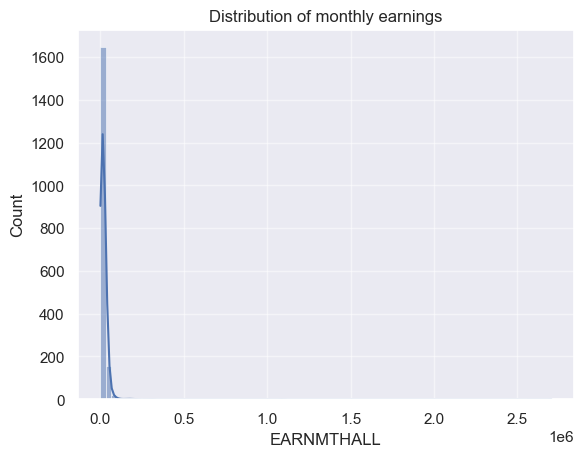

In [104]:
#Построим гистограмму для целевой переменной, чтобы понять её распределение
sns.histplot(data['earnmthall'], kde=True)
plt.title('Distribution of monthly earnings')
plt.xlabel('EARNMTHALL')
plt.ylabel('Count')
plt.show()

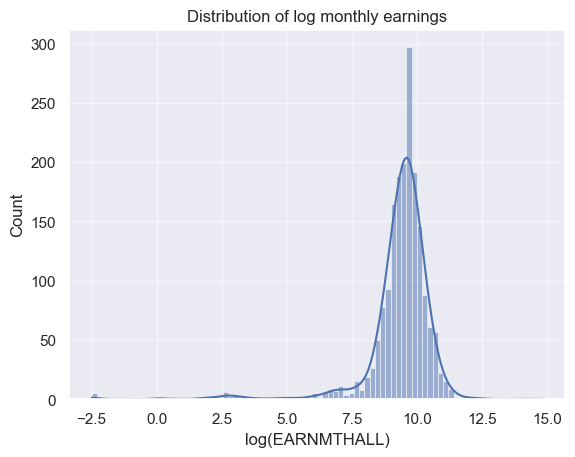

In [105]:

data['earnmthall'] = np.log(data['earnmthall'])

sns.histplot(data['earnmthall'], kde=True)
plt.title('Distribution of log monthly earnings')
plt.xlabel('log(EARNMTHALL)')
plt.ylabel('Count')

plt.show()

### Проверьте, есть ли дубликаты и пропуски
- покажите количество полных дубликатов в данных;
- покажите число пропущенных значений по всем переменным.


In [106]:
#Проверим наличие дубликатов при помощи метода duplicated
print(f"Duplicated rows {data.duplicated().sum()}")
#Проверим наличие пропусков при помощи метода isna
missing_values = data.isna().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing_values)



Duplicated rows 0
Missing values per column:
learnatwork    244
planning       197
firmsize       192
influence      189
taskdisc       104
pared           95
readhome        60
occupation      15
skills          14
courses         11
health           9
education        2
gender_r         1
sector           1
children         1
age_r            0
pvlit1           0
workhours        0
earnmthall       0
pvnum1           0
dtype: int64


### Уберите пропуски
Используйте `sklearn` `SimpleImputer` для следующего:

- заполните пропуски в `'gender_r','sector','firmsize','health','children','pared','education','skills','occupation','courses'` **медианой**;
- заполните пропуски в `'learnatwork', 'planning', 'influence', 'taskdisc', 'readhome'` **модой**.

После этого покажите суммарное количество пропусков во всём датасете.


In [107]:
from sklearn.impute import SimpleImputer
features1 = ['gender_r','sector','firmsize','health','children','pared','education','skills','occupation','courses']
features2 = ['learnatwork', 'planning', 'influence', 'taskdisc', 'readhome']

#разделим группу 1 на числа и категории
features1_numeric=data[features1].select_dtypes(include=['number']).columns
features1_categorical=data[features1].select_dtypes(exclude=['number']).columns
print("Numeric features1:", features1_numeric)
print("Categorical features1:", features1_categorical)
median_imputer = SimpleImputer(strategy='median')
data[features1_numeric] = median_imputer.fit_transform(data[features1_numeric])
"""для части данных из первой группы (медиана) применяем заполнение через моду, потому что медианой нельзя заполнить категории
можно использовать обратно перекодировку в число, но для occupation в любом случае это неприменимо, потому что код профессии не имеет "числового" выражения как такового, то есть его нельзя сравнить по принципу больше/меньше
для других столбцов мы ранее укрупнили категории, обратная перекодировка уже не вернет исходные данные, поэтому также используем моду
"""
freq_imputer = SimpleImputer(strategy='most_frequent')
data[features1_categorical] = freq_imputer.fit_transform(data[features1_categorical])
data[features2] = freq_imputer.fit_transform(data[features2])

Numeric features1: Index(['gender_r', 'sector', 'firmsize', 'children', 'pared', 'courses'], dtype='object')
Categorical features1: Index(['health', 'education', 'skills', 'occupation'], dtype='object')


In [108]:
missing_values = data.isna().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing_values)
#пропусков больше нет

Missing values per column:
age_r          0
gender_r       0
sector         0
firmsize       0
workhours      0
health         0
children       0
pared          0
education      0
skills         0
occupation     0
pvlit1         0
pvnum1         0
courses        0
earnmthall     0
learnatwork    0
influence      0
planning       0
readhome       0
taskdisc       0
dtype: int64


## Задание 3: описание данных (0–2 балла)

In [109]:
data.head(10)

,age_r,gender_r,sector,firmsize,workhours,health,children,pared,education,skills,occupation,pvlit1,pvnum1,courses,earnmthall,learnatwork,influence,planning,readhome,taskdisc
0,41,2.0,2.0,4.0,20.0,poor,2.0,2.0,higher,skilled,technicians,330.50218,305.30869,0.0,8.829568,2.295177,0.790227,1.315927,2.011665,1.369796
1,29,2.0,2.0,2.0,36.0,good,2.0,3.0,higher,skilled,professionals,282.35156,266.30648,0.0,9.745859,1.501159,1.891198,1.752098,1.235917,2.134559
2,53,1.0,2.0,4.0,40.0,poor,1.0,2.0,higher,skilled,professionals,285.95787,284.63605,0.0,9.210340,-0.204802,0.366385,1.068287,1.212887,0.696290
4,24,2.0,1.0,3.0,40.0,good,1.0,2.0,higher,semiskilled_white_collar,clerks_service_workers,260.96999,264.24711,0.0,10.126631,1.445971,0.109295,1.752098,0.276765,1.168926
6,44,2.0,1.0,2.0,40.0,good,1.0,2.0,higher,skilled,professionals,295.13639,281.70096,0.0,9.721166,0.844204,0.109295,1.752098,2.001743,2.311937
10,23,2.0,1.0,2.0,40.0,very good,2.0,3.0,higher,skilled,technicians,310.31094,315.27749,1.0,10.502782,0.069229,2.417422,1.561355,1.770721,2.207290
14,41,2.0,2.0,5.0,40.0,good,1.0,2.0,higher,semiskilled_white_collar,clerks_service_workers,283.82682,279.99767,0.0,9.017968,-0.186558,0.907427,0.561479,0.480203,0.535190
15,22,1.0,1.0,3.0,50.0,very good,2.0,2.0,general,skilled,professionals,268.11028,289.96483,0.0,9.903488,2.793005,3.237366,3.734814,0.884276,0.019412
18,41,1.0,2.0,2.0,48.0,good,1.0,3.0,higher,skilled,professionals,208.55415,238.47009,0.0,9.760387,0.844204,0.999594,0.797052,-0.034919,2.403887
19,36,2.0,2.0,3.0,56.0,good,1.0,2.0,professional,skilled,technicians,248.19400,239.07427,1.0,10.414313,1.325974,1.138650,1.248800,1.929618,1.617053


### Примените one-hot encoding к категориальным шкалам

Используйте переменные из `features1`. При кодировании удалите первую категорию у каждого признака, чтобы избежать мультиколлинеарности. Не забудьте присоединить закодированные данные к общему датасету и удалить исходные категориальные шкалы. Покажите размер преобразованного датафрейма. Он должен быть **(1827, 31)**.


In [110]:
from sklearn.preprocessing import OneHotEncoder
data.reset_index(inplace = True)
data.drop(columns='index', inplace = True)
#переведем столбцы первой группы в строки, иначе valueError
data[features1] = data[features1].astype(str)
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_values = encoder.fit_transform(data[features1])
encoded_columns = encoder.get_feature_names_out(features1)
encoded_data = pd.DataFrame(encoded_values, columns=encoded_columns)
data = data.drop(columns=features1)
data = pd.concat([data, encoded_data], axis=1)
data.shape


(1827, 31)

### Описательная статистика
Покажите таблицу описательной статистики для всех переменных со столбцами `mean`, `std`, `min`, `max`, округлив значения до двух знаков после запятой.


In [111]:
stats = data.describe().T[['mean', 'std', 'min', 'max']].round(2)
display(stats)

,mean,std,min,max
age_r,36.22,12.47,16.00,65.00
workhours,38.74,12.21,1.00,80.00
pvlit1,283.45,39.60,133.77,407.18
pvnum1,277.88,38.35,136.11,383.84
earnmthall,9.32,1.38,-2.48,14.81
learnatwork,1.72,1.09,-0.64,4.16
influence,2.03,0.95,0.06,5.58
planning,1.95,0.95,0.10,3.73
readhome,1.34,1.12,-1.30,7.43
taskdisc,1.73,0.92,-0.23,4.30


### Корреляции
- создайте датафрейм `X` только с признаками;
- создайте `y` только с целевой переменной;
- постройте горизонтальный barplot, показывающий корреляцию между целевой переменной и всеми признаками, отсортировав по размеру коэффициента корреляции.


In [112]:
X=data.drop(columns='earnmthall')
Y=data['earnmthall']
correlations = X.corrwith(Y).sort_values(ascending=False)
correlations


workhours                            0.240352
pvnum1                               0.128520
learnatwork                          0.118187
pvlit1                               0.109008
education_higher                     0.108011
firmsize_5.0                         0.070815
health_very good                     0.067984
occupation_senior_officials          0.060706
occupation_technicians               0.053581
planning                             0.050384
firmsize_3.0                         0.041393
firmsize_4.0                         0.037894
courses_1.0                          0.026202
pared_3.0                            0.025095
pared_2.0                            0.024863
skills_skilled                       0.024791
readhome                             0.024525
influence                            0.018192
occupation_clerks_service_workers    0.000024
skills_semiskilled_white_collar      0.000024
children_2.0                        -0.007779
age_r                             

### Визуальный анализ
Постройте `pairplot` для целевой переменной и четырёх непрерывных шкал, у которых корреляция с целевой переменной выше 0.04. Под диагональю должны быть scatter plots, а на диагонали — гистограммы.


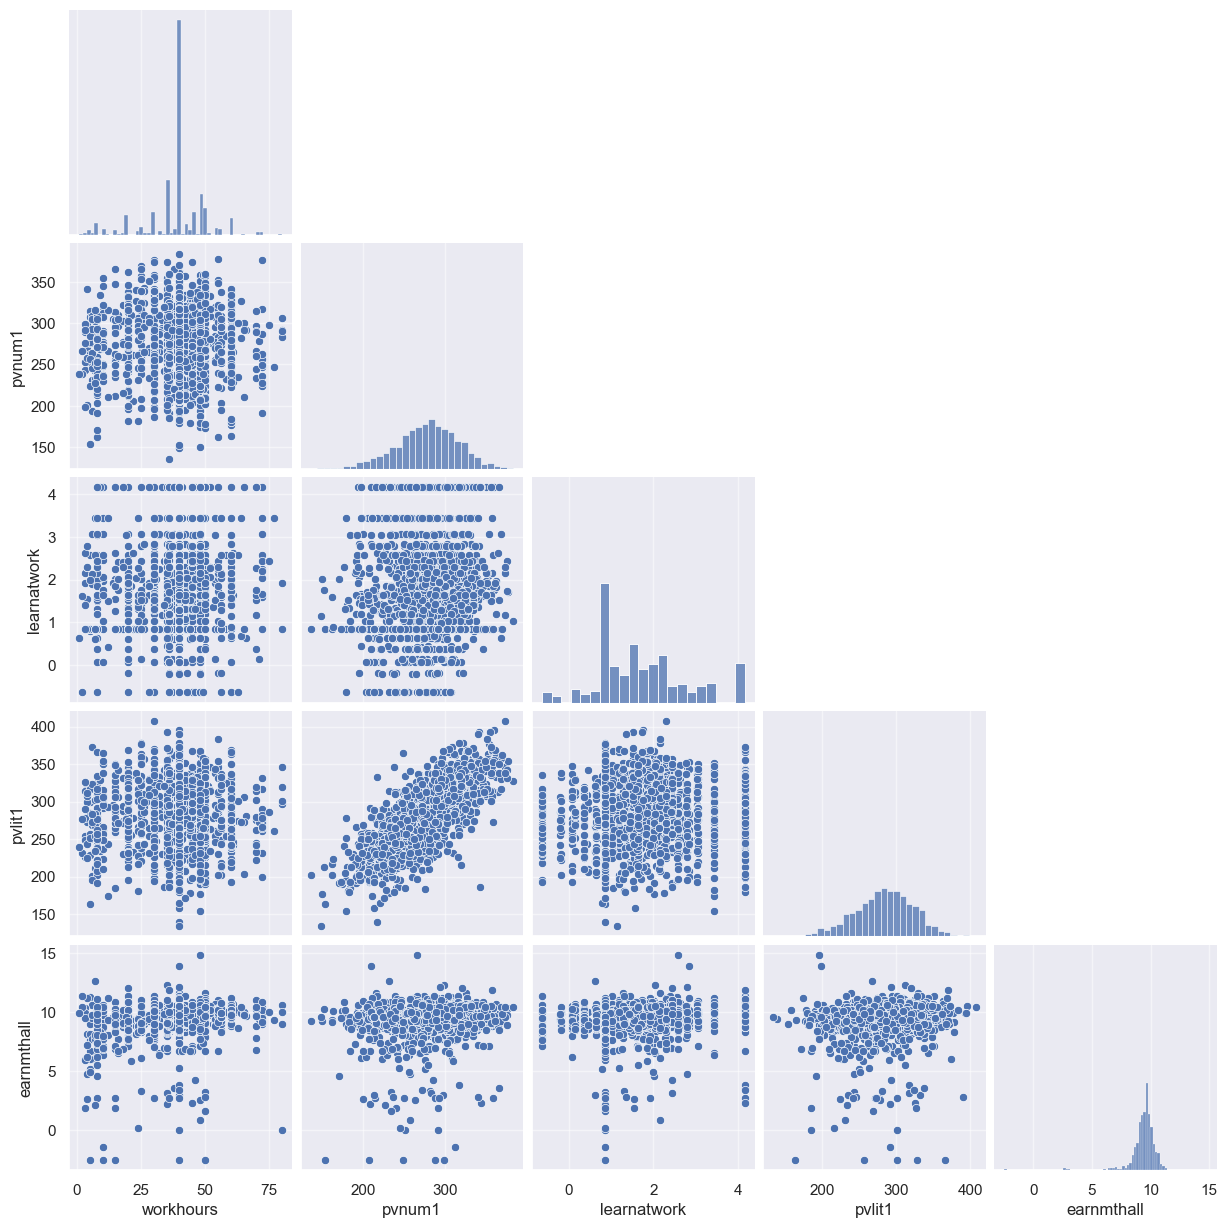

In [113]:
continuous_scales = [
    'age_r',
    'workhours',
    'pvlit1',
    'pvnum1',
    'learnatwork',
    'influence',
    'planning',
    'readhome',
    'taskdisc'
]
continuous_correl=X[continuous_scales].corrwith(Y).sort_values(ascending=False)
selected_features = continuous_correl[
    continuous_correl > 0.04
].head(4).index.tolist()
a=data[selected_features + ['earnmthall']]
sns.pairplot(a, corner=True, diag_kind='hist'
)
plt.show()
#на графике пересечения pvlit1 и pvnum1 "вырисовывается" прямая вида y=kx+b, что говорит о сильной корелляции


In [114]:
#проверим pairplot по матрице корелляции
corr_matrix = a.corr(numeric_only=True)
corr_matrix
#данные в pairplot соответствуют данным матрицы, это видно по pvnum1 и pvlit1, у которых коэф. 0.76

,workhours,pvnum1,learnatwork,pvlit1,earnmthall
workhours,1.000000,0.034295,0.061744,0.016839,0.240352
pvnum1,0.034295,1.000000,0.088935,0.763558,0.128520
learnatwork,0.061744,0.088935,1.000000,0.031456,0.118187
pvlit1,0.016839,0.763558,0.031456,1.000000,0.109008
earnmthall,0.240352,0.128520,0.118187,0.109008,1.000000


Судя по графику выше, некоторые признаки сильно коррелируют друг с другом, а это может привести к проблеме мультиколлинеарности. Давайте с этим разберёмся.


## Задание 4: отбор признаков, преобразование переменных и OLS (0–2 балла)

### Отбор признаков
- поскольку `pvlit1` сильно коррелирует с `pvnum1`, удалите `pvlit1` из данных `X`;
- разделите `X` и `y` на обучающую и тестовую выборки;
- покажите размер `X_train` и `X_test`.


In [115]:
from sklearn.model_selection import train_test_split
X=data.drop(columns=['earnmthall','pvlit1'])
Y=data['earnmthall']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=10)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (1278, 29)
X_test shape: (549, 29)


### Масштабирование числовых данных

Выполните стандартное масштабирование непрерывных шкал (расширенный список `features2`).

Добавьте к `features2` переменные:
- `age_r`
- `pvnum1`
- `workhours`


In [116]:
features2.extend(['age_r', 'pvnum1', 'workhours'])

In [117]:
from sklearn.preprocessing import StandardScaler
print(features2)
scaler = StandardScaler()
X_train[features2] = scaler.fit_transform(X_train[features2])
X_test[features2] = scaler.transform(X_test[features2])
X_train.head()





['learnatwork', 'planning', 'influence', 'taskdisc', 'readhome', 'age_r', 'pvnum1', 'workhours']


,age_r,workhours,pvnum1,learnatwork,influence,planning,readhome,taskdisc,gender_r_2.0,sector_2.0,firmsize_2.0,firmsize_3.0,firmsize_4.0,firmsize_5.0,health_poor,health_very good,children_2.0,pared_2.0,pared_3.0,education_higher,education_professional,skills_semiskilled_white_collar,skills_skilled,occupation_clerks_service_workers,occupation_elementary_occupations,occupation_professionals,occupation_senior_officials,occupation_technicians,courses_1.0
247,1.161260,0.093563,0.207521,-0.364230,0.068701,-0.179795,-0.183099,-1.054518,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1211,-1.060076,-1.926256,-0.590775,-0.424055,0.182938,-0.179795,-2.144116,0.738950,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1405,0.685259,-2.491805,-2.262519,0.406045,-0.535598,-0.179795,-0.309823,0.731952,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
194,1.954594,0.093563,-0.865348,-0.797088,0.182938,-0.179795,-1.746503,-0.895043,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1337,-0.504742,0.093563,0.133608,0.524349,-0.254703,-0.179795,-2.355228,-2.127812,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Обучите регрессию (OLS)
- обучите обычную линейную регрессию (OLS);
- сделайте предсказания;
- покажите *RMSE* и $R^2$ на обучающей и тестовой выборках.


In [118]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
ols=LinearRegression().fit(X_train, y_train)
y_pred_train=ols.predict(X_train)
y_pred_test=ols.predict(X_test)

rmse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
rmse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
print(f"Train RMSE: {rmse_train:.4f}, Train R^2: {r2_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}, Test R^2: {r2_test:.4f}")

Train RMSE: 1.9711, Train R^2: 0.1091
Test RMSE: 1.1328, Test R^2: 0.0758


### Покажите коэффициенты

Постройте горизонтальный bar plot: по оси `y` — признаки, по оси `x` — коэффициенты. Отсортируйте по величине коэффициента.


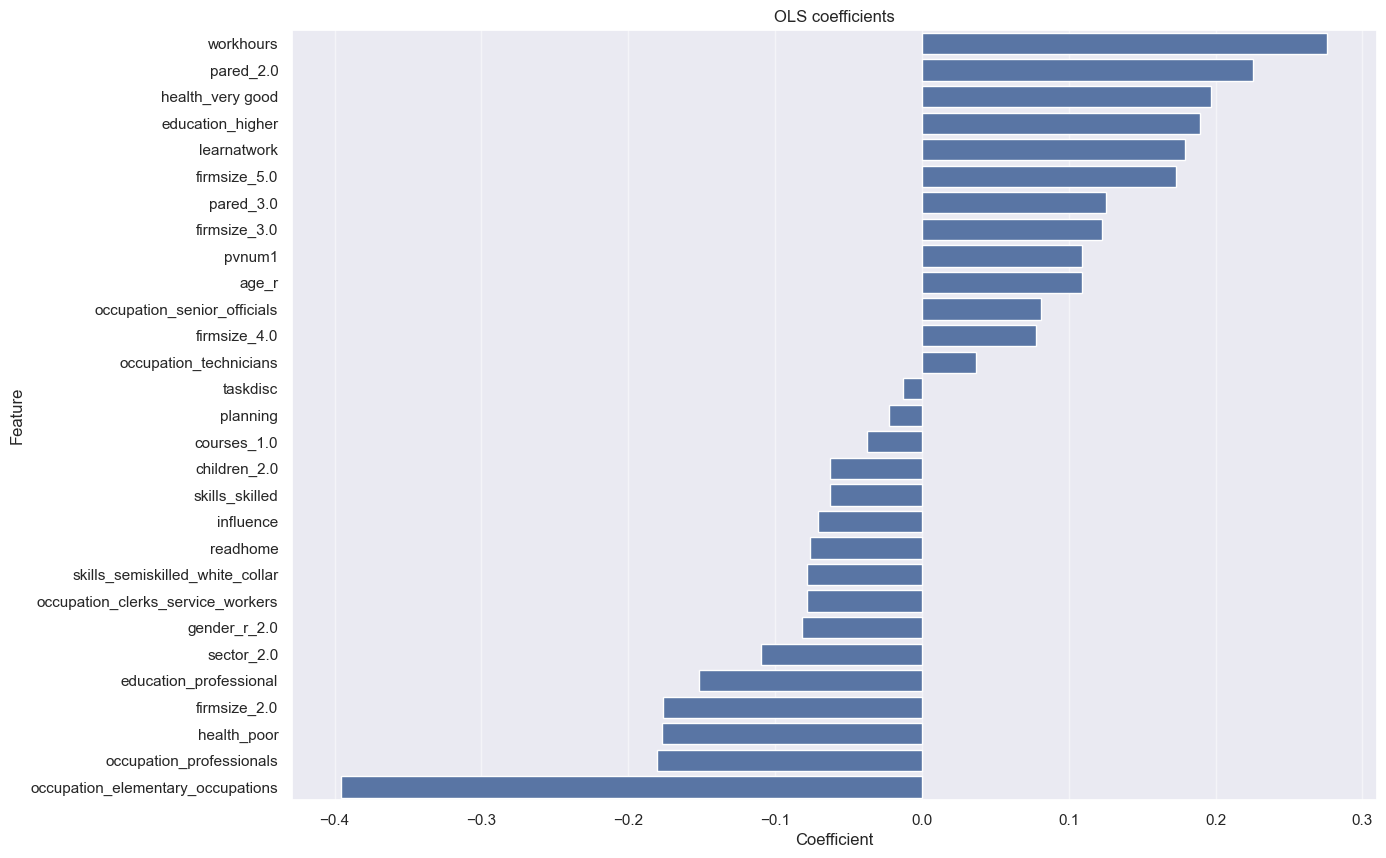

In [119]:
ols.coef_
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': ols.coef_
})
coef_df = coef_df.sort_values(by='coefficient', ascending=False)
plt.figure(figsize=(14, 10))
sns.barplot(data=coef_df, x='coefficient', y='feature')
plt.title('OLS coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

## Задание 5: регрессия с регуляризацией (0–2 балла)

### Подберите лучшее alpha для ridge-регрессии с помощью grid search

Подберите диапазон `alpha` так, чтобы по графику cross-validation было видно нечто похожее на параболу. Посмотрите на пример из лекции. Используйте 4 фолда.


Best alpha = 184.2070


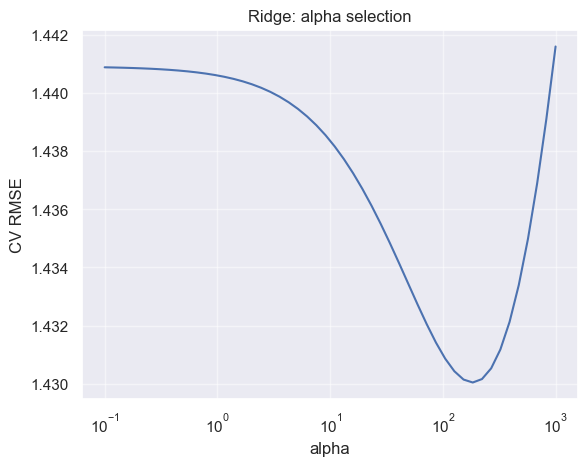

In [120]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
alphas = np.logspace(-1, 3, 50)

searcher = GridSearchCV(
    Ridge(),
    {'alpha': alphas},
    scoring='neg_root_mean_squared_error',
    cv=4
)
searcher.fit(X_train, y_train)
best_alpha = searcher.best_params_['alpha']
print(f'Best alpha = {best_alpha:.4f}')

plt.plot(alphas, -searcher.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV RMSE');
plt.title('Ridge: alpha selection')
plt.show()



### Ridge-регрессия
- обучите ridge-регрессию с лучшим `alpha`;
- сделайте предсказания;
- покажите *RMSE* и $R^2$ на обучающей и тестовой выборках;
- постройте bar plot коэффициентов.


Train RMSE: 1.4101, Train R^2: 0.1013
Test RMSE: 1.0448, Test R^2: 0.1094


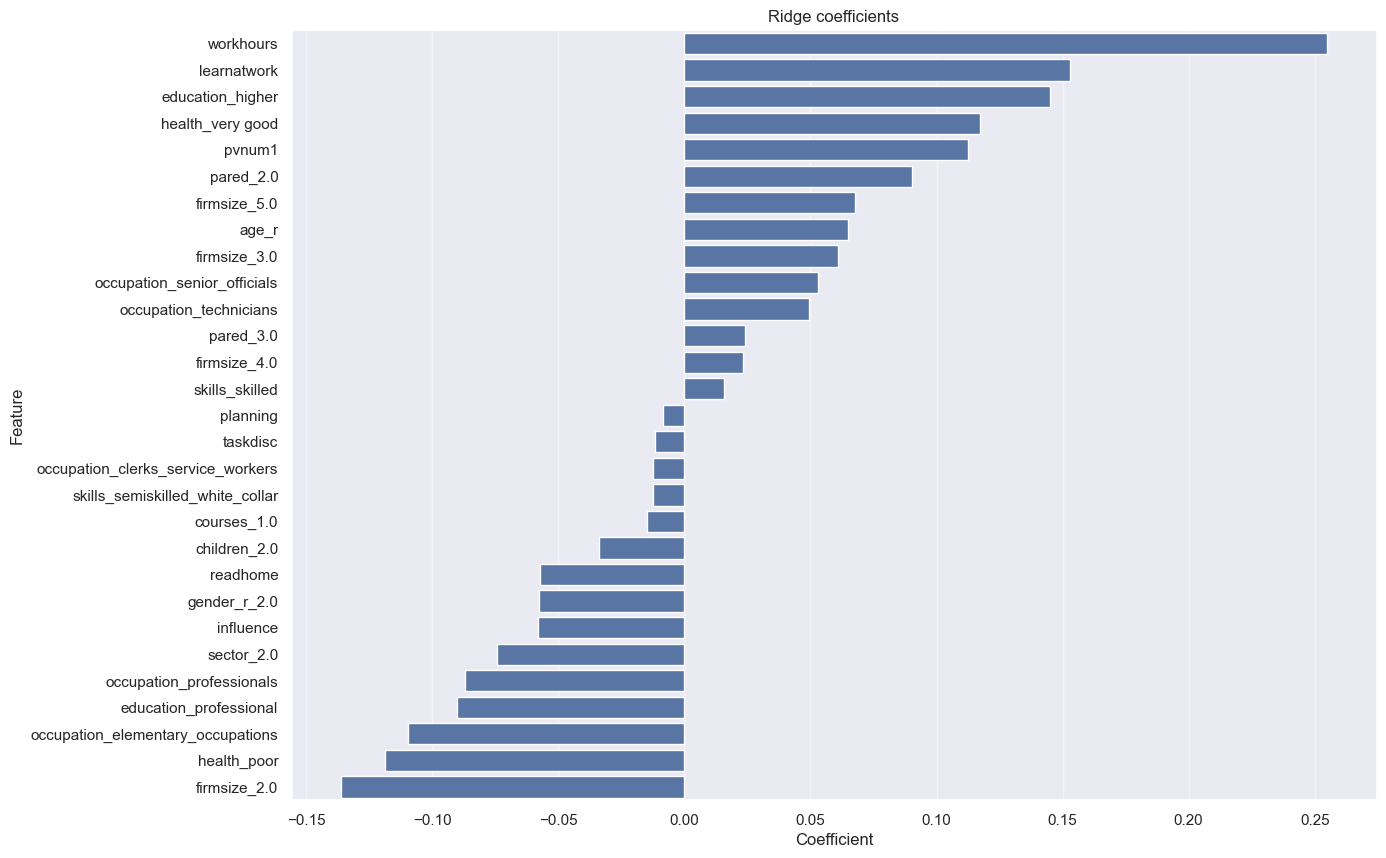

In [121]:
ridge = Ridge(alpha=best_alpha).fit(X_train, y_train)
y_pred_train_ridge = ridge.predict(X_train)
y_pred_test_ridge = ridge.predict(X_test)
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_ridge)):.4f}, Train R^2: {r2_score(y_train, y_pred_train_ridge):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_ridge)):.4f}, Test R^2: {r2_score(y_test, y_pred_test_ridge):.4f}")
ridge_coefs=pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': ridge.coef_
})
ridge_coefs = ridge_coefs.sort_values('coefficient', ascending=False)
plt.figure(figsize=(14, 10))

sns.barplot(
    data=ridge_coefs, x='coefficient', y='feature'
)

plt.title('Ridge coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()
#по barplot можно увидеть, что после ridge амплитуда коэффициентов стала меньше по сравнению с OLS

### Подберите лучшее alpha для lasso-регрессии с помощью grid search

Подберите диапазон `alpha` так, чтобы по графику cross-validation было видно нечто похожее на параболу. Посмотрите на пример из лекции. Используйте 4 фолда.


Best alpha = 0.1000


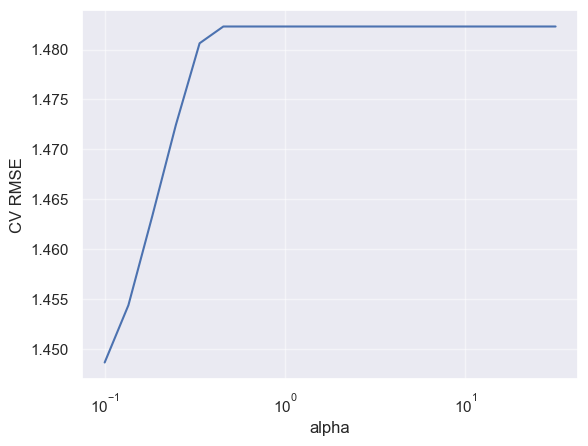

In [122]:
from sklearn.linear_model import Lasso
alphas = np.logspace(-1, 1.5, 20)
searcher = GridSearchCV(Lasso(),
                        {'alpha': alphas},
                        scoring='neg_root_mean_squared_error',
                        cv=4)
searcher.fit(X_train, y_train)

best_alpha = searcher.best_params_['alpha']
print(f'Best alpha = {best_alpha:.4f}')

plt.plot(alphas, -searcher.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV RMSE');


Best alpha = 0.0161


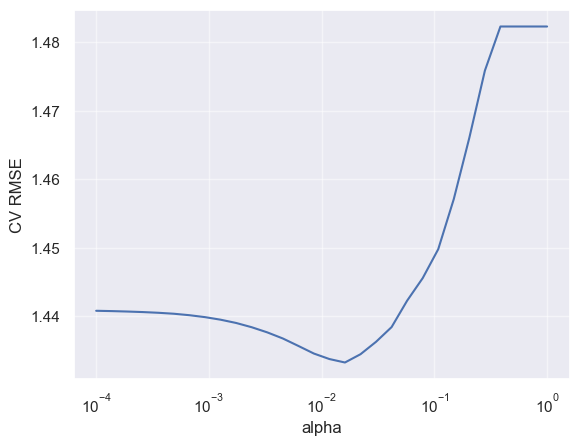

In [123]:
#на графике видно, что минимум расположен на краю, примерно на x=0.5, подберем другой logspace
alphas = np.logspace(-4, 0, 30)
searcher = GridSearchCV(Lasso(),
                        {'alpha': alphas},
                        scoring='neg_root_mean_squared_error',
                        cv=4)
searcher.fit(X_train, y_train)

best_alpha_lasso = searcher.best_params_['alpha']
print(f'Best alpha = {best_alpha_lasso:.4f}')

plt.plot(alphas, -searcher.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV RMSE')
plt.show()

### Lasso-регрессия

- обучите lasso-регрессию с лучшим `alpha`;
- сделайте предсказания;
- покажите *RMSE* и $R^2$ на обучающей и тестовой выборках;
- постройте bar plot коэффициентов, используя только **ненулевые** коэффициенты.


Train RMSE: 1.4127, Train R^2: 0.0980
Test RMSE: 1.0439, Test R^2: 0.1109
N features used: 16


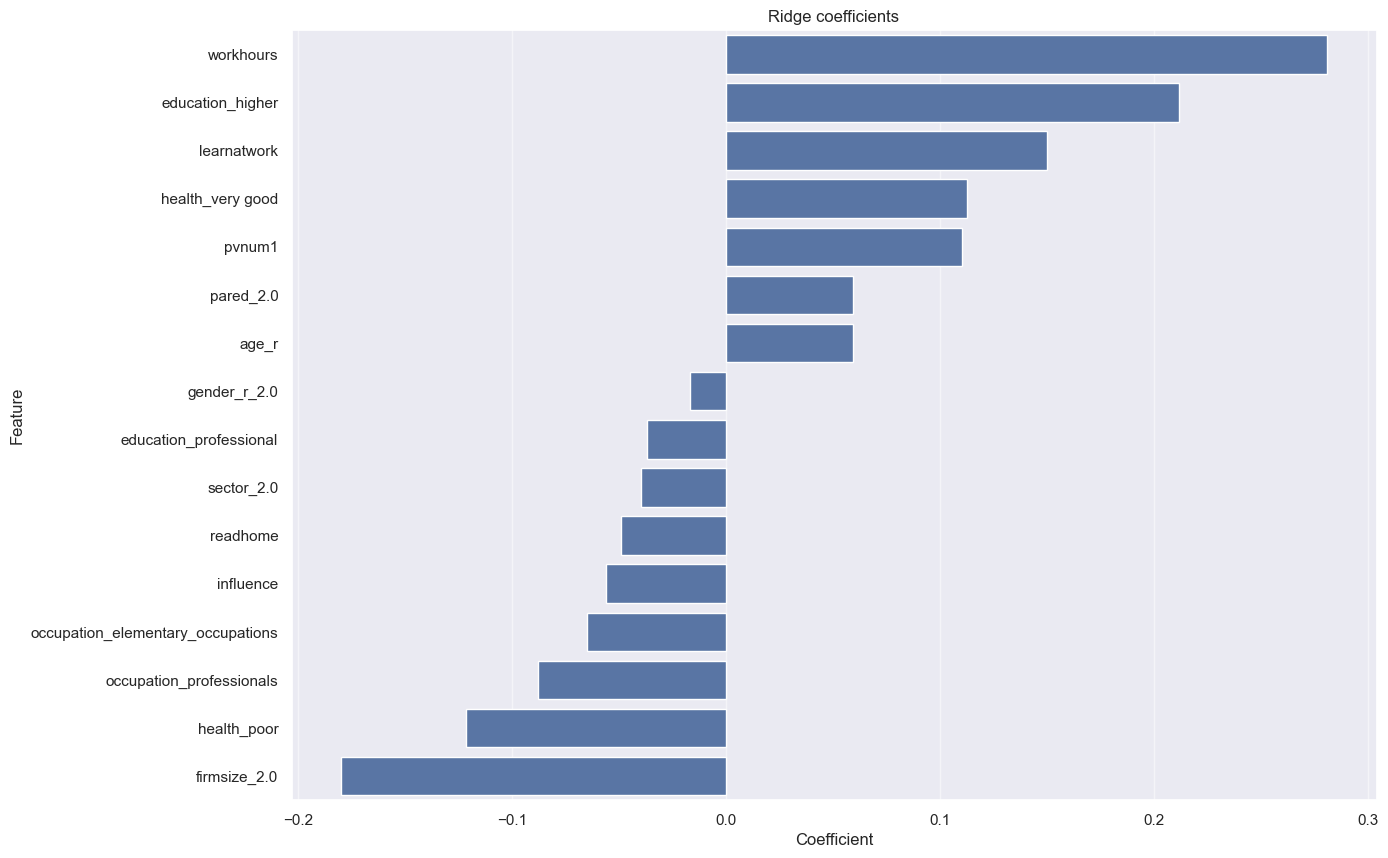

In [124]:
lasso=Lasso(alpha=best_alpha_lasso).fit(X_train, y_train)
y_pred_train_lasso=lasso.predict(X_train)
y_pred_test_lasso=lasso.predict(X_test)
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_lasso)):.4f}, Train R^2: {r2_score(y_train, y_pred_train_lasso):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_lasso)):.4f}, Test R^2: {r2_score(y_test, y_pred_test_lasso):.4f}")
print(f'N features used: {np.sum(lasso.coef_ != 0)}')
lasso_coefs=pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lasso.coef_
})
lasso_coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lasso.coef_
})
lasso_coefs = lasso_coefs[lasso_coefs['coefficient'] != 0]
lasso_coefs = lasso_coefs.sort_values('coefficient', ascending=False)
plt.figure(figsize=(14, 10))

sns.barplot(
    data=lasso_coefs, x='coefficient', y='feature'
)

plt.title('Ridge coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()
